# **Подготовка данных**

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv1D, Flatten, LSTM, Dropout
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator

!pip install yfinance

import yfinance as yf

# Скачиваем данные Лукойла (тикер LKOH.ME для Мосбиржи)
# Период 'max' или конкретные даты, например с 2010 года
data_yf = yf.download('LKOH.ME', start='2010-01-01')

# Extract only the 'Close' price for 'LKOH.ME' and rename the column to 'CLOSE'
# The yf.download output 'data_yf' has multi-level columns like ('Close', 'LKOH.ME')
close_prices = data_yf[('Close', 'LKOH.ME')]

# Convert to a DataFrame with a single column named 'CLOSE'
data_to_save = close_prices.to_frame(name='CLOSE')

# Сохраняем только цену 'CLOSE' в 1luk.csv
data_to_save.to_csv('1luk.csv')

print("Данные скачаны и сохранены в 1luk.csv")
# 1. Загрузка данных (убедитесь, что файл 1luk.csv загружен в Colab)
# Исправлена ошибка: использовать запятую (',') в качестве разделителя, так как to_csv по умолчанию использует запятую.
df = pd.read_csv('1luk.csv', sep=',')
# Теперь 'CLOSE' является прямой колонкой в df.
data = df['CLOSE'].values.reshape(-1, 1)

# 2. Масштабирование
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

# Параметры
win_len = 30 # берем историю за 30 дней
batch_size = 32

# Разделение на обучающую и тестовую выборки (последние 20% для теста)
train_len = int(len(data_scaled) * 0.8)

# Генератор для предсказания на 1 шаг вперед (Задание 1)
train_gen = TimeseriesGenerator(data_scaled, data_scaled, length=win_len, batch_size=batch_size, end_index=train_len)
test_gen = TimeseriesGenerator(data_scaled, data_scaled, length=win_len, batch_size=batch_size, start_index=train_len)

/tmp/ipykernel_9591/688589883.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data_yf = yf.download('LKOH.ME', start='2010-01-01')
[*********************100%***********************]  1 of 1 completed

Данные скачаны и сохранены в 1luk.csv


# **Простая полносвязная сеть (Dense)**

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.0487
Epoch 2/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0025
Epoch 3/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0071
Epoch 4/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0033
Epoch 5/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0027
Epoch 6/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0038
Epoch 7/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0031
Epoch 8/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0056
Epoch 9/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0020
Epoch 10/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0025
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


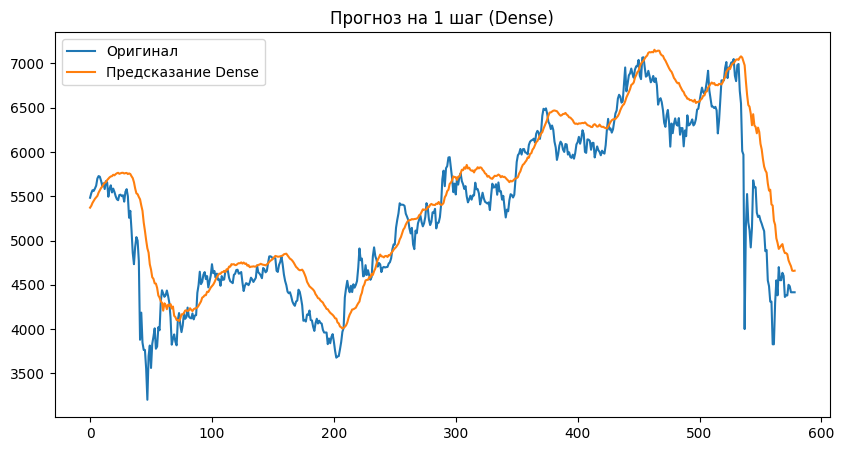

In [4]:
model_dense = Sequential([
    Dense(64, activation='relu', input_shape=(win_len, 1)),
    Flatten(),
    Dense(1)
])

model_dense.compile(optimizer='adam', loss='mse')
model_dense.fit(train_gen, epochs=10)

# Визуализация
predictions = model_dense.predict(test_gen)
y_true = data[train_len + win_len:]
y_pred = scaler.inverse_transform(predictions)

plt.figure(figsize=(10, 5))
plt.plot(y_true, label='Оригинал')
plt.plot(y_pred, label='Предсказание Dense')
plt.title('Прогноз на 1 шаг (Dense)')
plt.legend()
plt.show()

# **Прогноз на 10 шагов вперед и визуализация**

Epoch 1/15


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


77/77 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0334
Epoch 2/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0031
Epoch 3/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0031
Epoch 4/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0028
Epoch 5/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0027
Epoch 6/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0027
Epoch 7/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0033
Epoch 8/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0024
Epoch 9/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0024
Epoch 10/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0026
Epoch 11/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0022
Epoch 12/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0022
Epoch 13/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0023
Epoch 14/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0022
Epoch 15/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0023
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 

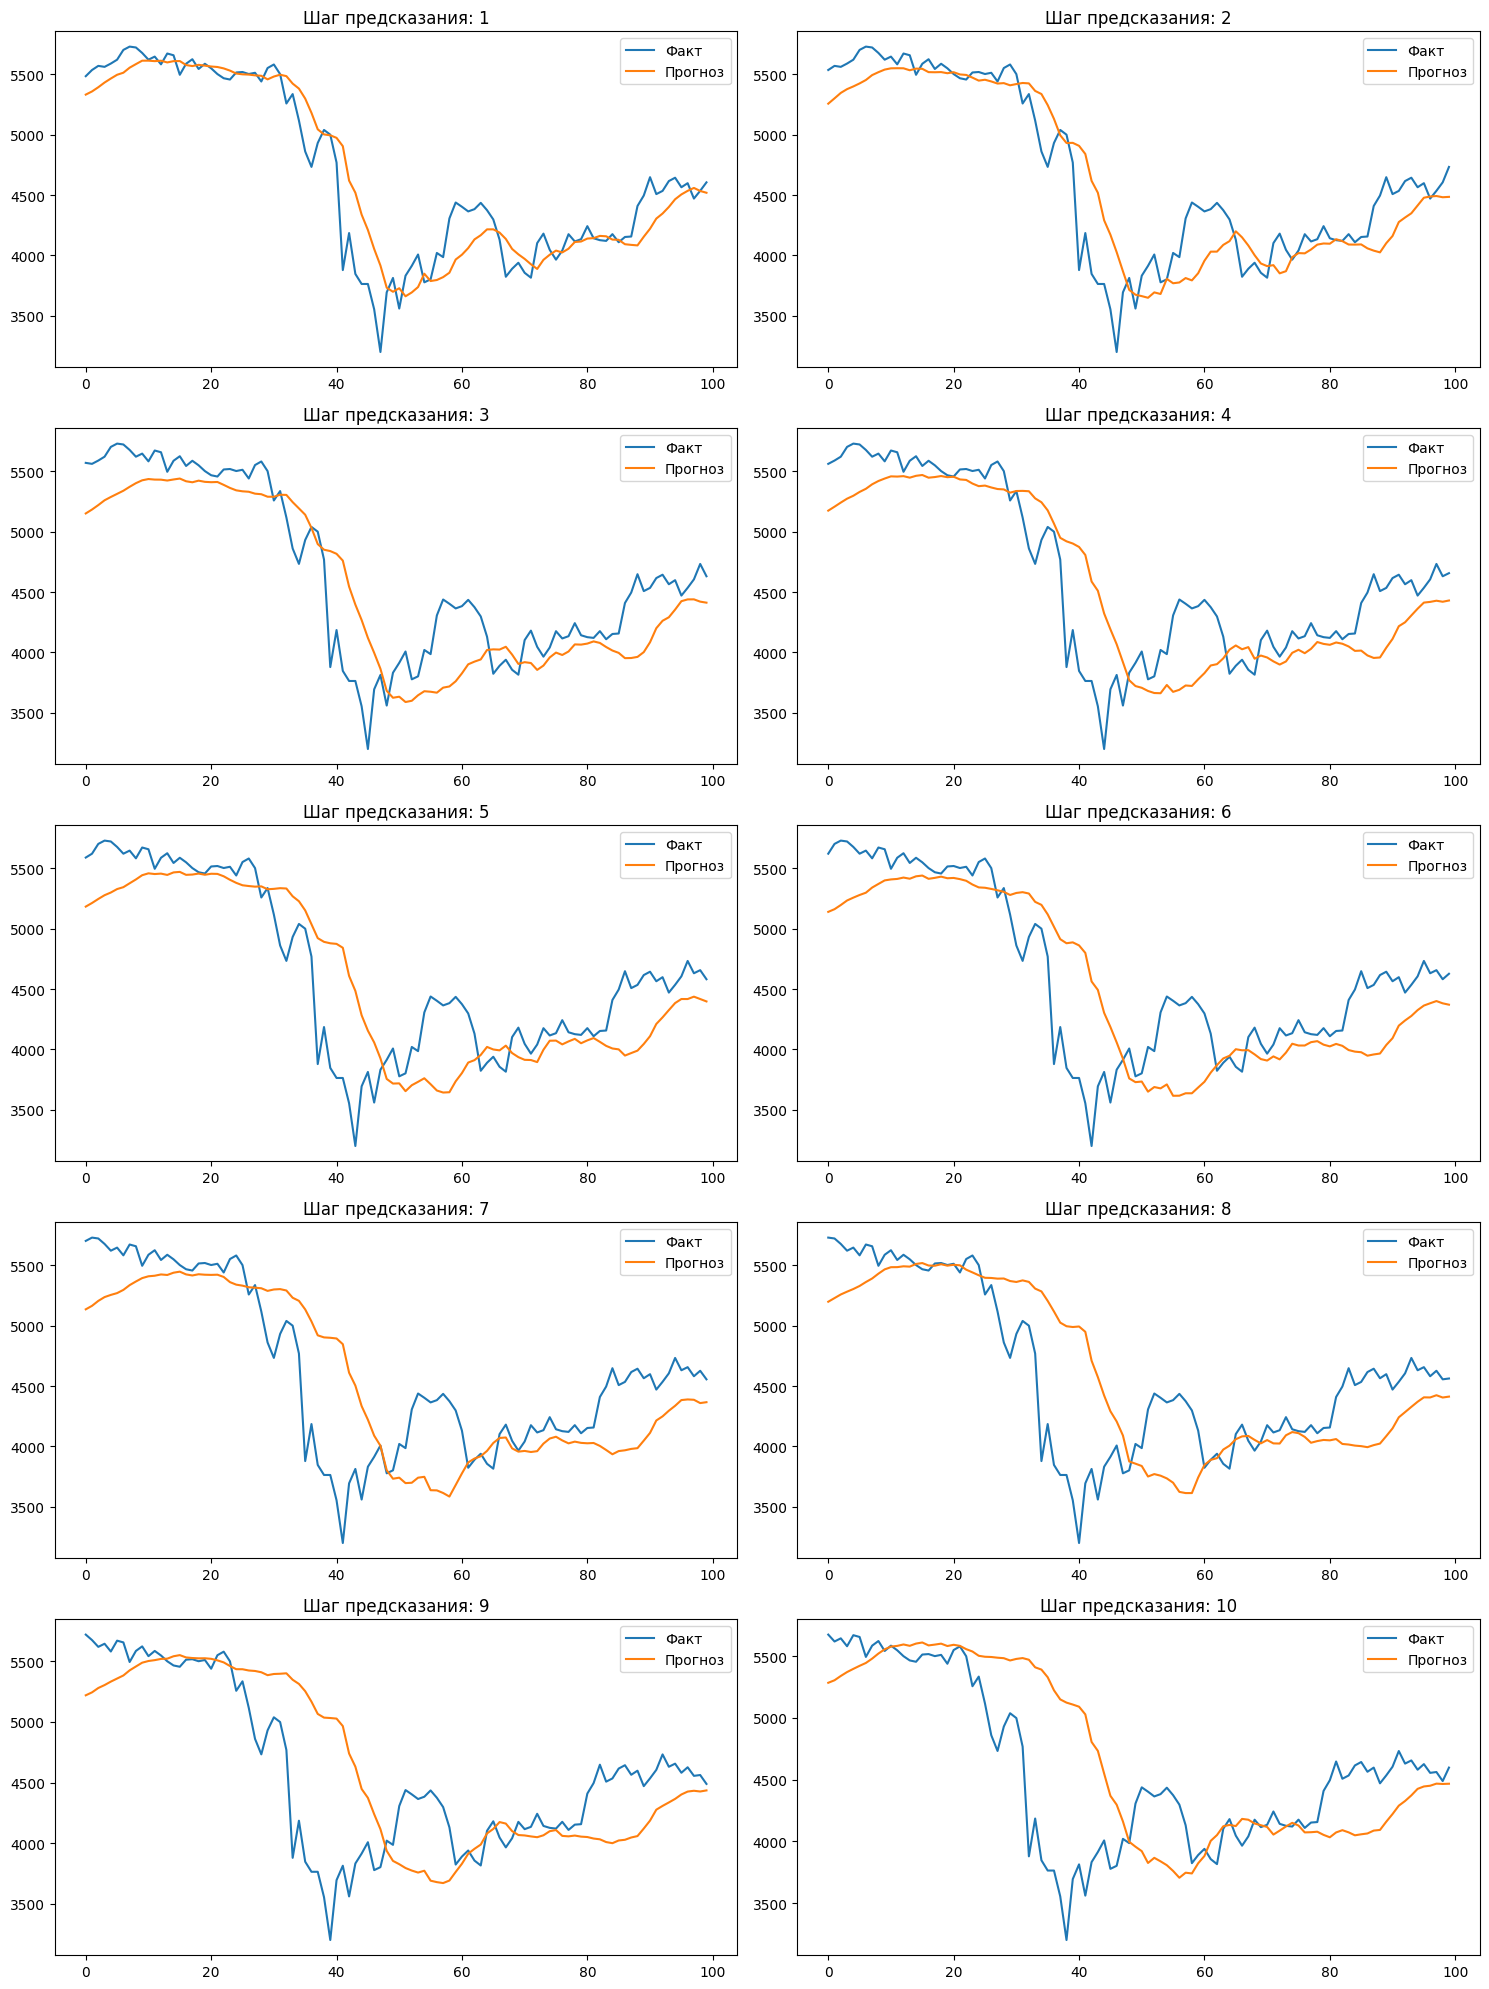

In [5]:
# Пересоздаем генераторы для 10 шагов
future_steps = 10
x_train_10, y_train_10 = [], []

for i in range(len(data_scaled) - win_len - future_steps):
    x_train_10.append(data_scaled[i : i + win_len])
    y_train_10.append(data_scaled[i + win_len : i + win_len + future_steps])

x_train_10, y_train_10 = np.array(x_train_10), np.array(y_train_10).reshape(-1, future_steps)

# Модель для 10 шагов
model_10 = Sequential([
    Dense(128, activation='relu', input_shape=(win_len, 1)),
    Flatten(),
    Dense(future_steps) # Выход на 10 шагов
])

model_10.compile(optimizer='adam', loss='mse')
model_10.fit(x_train_10[:train_len], y_train_10[:train_len], epochs=15, batch_size=32)

# Предсказание
pred_10 = model_10.predict(x_train_10[train_len:])
pred_10_rescaled = scaler.inverse_transform(pred_10)
true_10_rescaled = scaler.inverse_transform(y_train_10[train_len:])

# Задание 3: 10 графиков сравнения
fig, axes = plt.subplots(5, 2, figsize=(15, 20))
axes = axes.flatten()

for i in range(future_steps):
    axes[i].plot(true_10_rescaled[:100, i], label='Факт')
    axes[i].plot(pred_10_rescaled[:100, i], label='Прогноз')
    axes[i].set_title(f'Шаг предсказания: {i+1}')
    axes[i].legend()

plt.tight_layout()
plt.show()

# **Модель с использованием Conv1D или LSTM**

Epoch 1/15


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


77/77 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 0.1369
Epoch 2/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0118
Epoch 3/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0100
Epoch 4/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0084
Epoch 5/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0080
Epoch 6/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0073
Epoch 7/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0065
Epoch 8/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0065
Epoch 9/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0060
Epoch 10/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0054
Epoch 11/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0055
Epoch 12/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0054
Epoch 13/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0054
Epoch 14/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0052
Epoch 15/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0047
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 

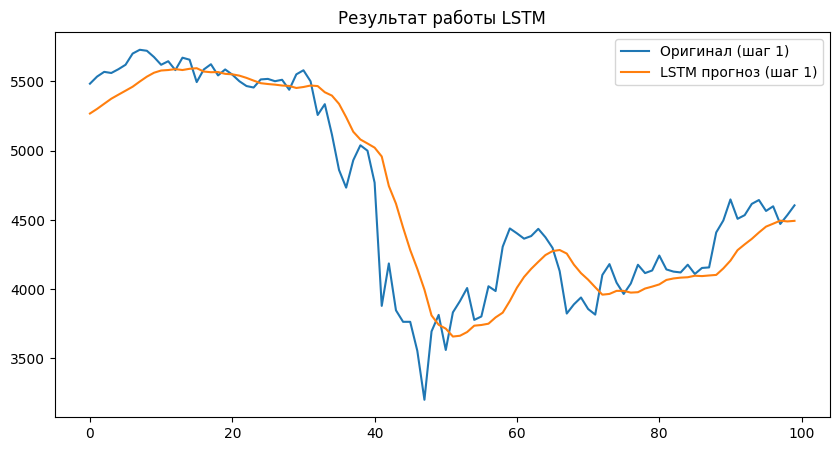

In [6]:
# Используем те же данные на 10 шагов, но с архитектурой LSTM
model_lstm = Sequential([
    LSTM(64, input_shape=(win_len, 1), return_sequences=False),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(future_steps)
])

model_lstm.compile(optimizer='adam', loss='mse')
model_lstm.fit(x_train_10[:train_len], y_train_10[:train_len], epochs=15, batch_size=32)

# Визуализация (аналогично пункту 2)
pred_lstm = model_lstm.predict(x_train_10[train_len:])
pred_lstm_rescaled = scaler.inverse_transform(pred_lstm)

plt.figure(figsize=(10, 5))
plt.plot(true_10_rescaled[:100, 0], label='Оригинал (шаг 1)')
plt.plot(pred_lstm_rescaled[:100, 0], label='LSTM прогноз (шаг 1)')
plt.title('Результат работы LSTM')
plt.legend()
plt.show()